# First Classification attempt - Problem baseline with group stratification

I'm going to use machine learning models to predict the injury status of the players with the data we have.
I do not expect to get good results, but I want to get a baseline to compare after improving the data and trying more advance techniques and models.

I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb


import joblib
import os

import core.constants as c
from core.utils import extract_subject_id
from core.model_selection import (
    train_model_with_cv_eval,
    evaluate_models,
    save_models_and_results,
    load_models_and_results,
    plot_comparison_and_confusion,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load train and test sets from disk
X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE, index_col=0)
X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE, index_col=0).squeeze()
y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE, index_col=0).squeeze()

## Model configuration

In [3]:
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0]
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 0.1, 0.01]
        }
    }
}


## Train Models with Grid Search

In [4]:
# Train stratified by groups
trained_models = train_model_with_cv_eval(
    X_train=X_train,
    y_train=y_train,
    groups=extract_subject_id(X_train.index),
    models_config=models_config,
    scoring='roc_auc',
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

# Evaluate
results = evaluate_models(trained_models, X_test=X_test, y_test=y_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

In [5]:
# Persist using utilities
results_model = save_models_and_results(
    trained_models=trained_models,
    eval_results=results,
    target_folder=c.RICKD_BASELINE_RESULTS_FOLDER_V2,
    results_summary_file=c.RICKD_BASELINE_RESULTS_SUMMARY_V2,
)
print(f"Results summary saved to: {c.RICKD_BASELINE_RESULTS_SUMMARY_V2}")

Results summary saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV2_stratified_group_kfold/results_summary.json


### Checkpoint: Load results and models

In [6]:
# Load using utilities
results, trained_models = load_models_and_results(
    results_summary_file=c.RICKD_BASELINE_RESULTS_SUMMARY_V2
)

## Analysis of Models

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
2              XGBoost        0.7551         0.7670          0.7744   
0  Logistic Regression        0.7464         0.7382          0.7366   
1        Random Forest        0.7405         0.7382          0.7756   
3                  SVM        0.7042         0.6780          0.6704   

   Test Recall  Test F1-Score  Test Best CV Score  
2       0.7670         0.7547              0.7487  
0       0.7382         0.7285              0.7543  
1       0.7382         0.7074              0.7389  
3       0.6780         0.6695              0.7547  

Best performing model: XGBoost
Best Test ROC AUC Score: 0.7551


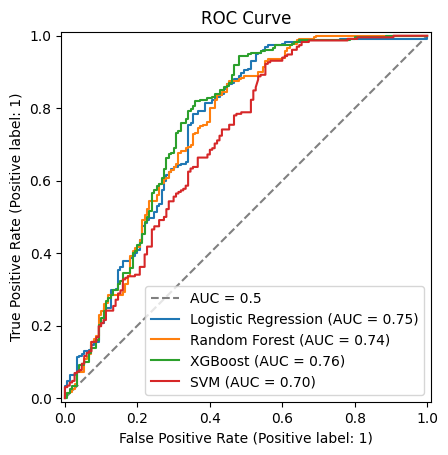

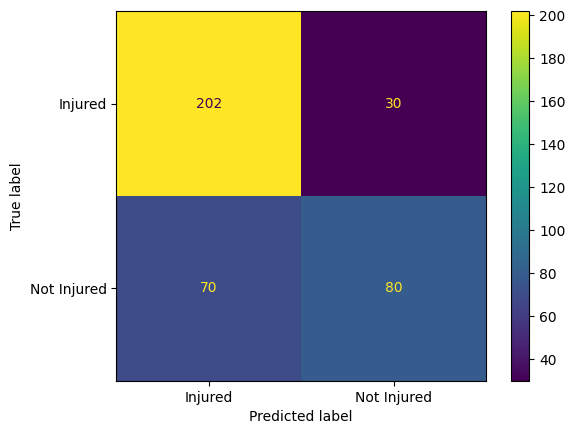

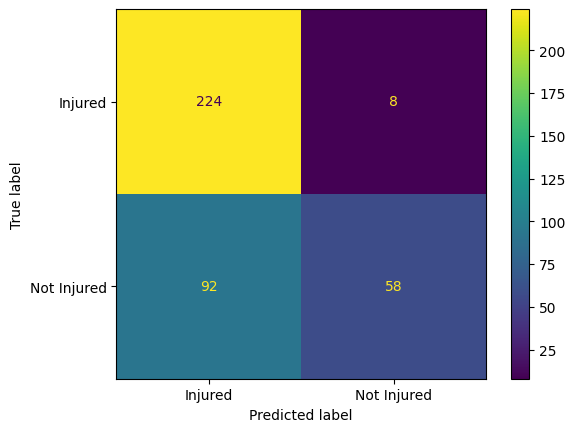

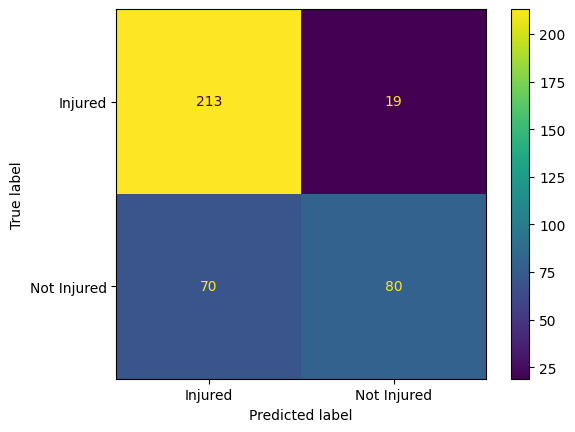

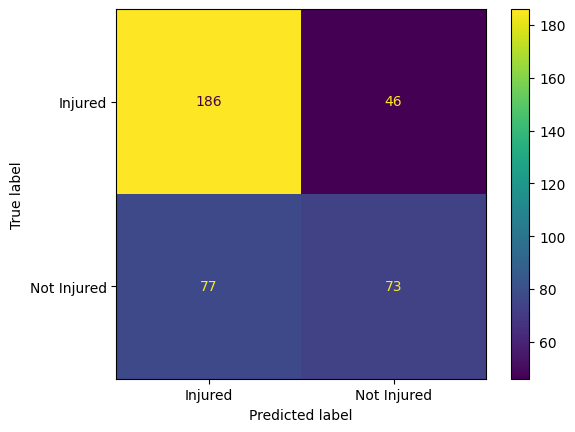

In [7]:
comparison_df = plot_comparison_and_confusion(
    results=results,
    y_test=y_test,
    class_labels=['Injured', 'Not Injured'],
    label_order=[1, 0],
)

PRIMARY_METRIC = 'Test ROC AUC'
print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")